# BiasAnalyzer workflow

This notebook runs a small end-to-end bias/variance study. It is designed for the separate `Python (fluq notebook)` kernel described below. The first code cell adds the repository root to `sys.path`, so edits to `bias_variance` are picked up without installing the project itself into the notebook environment.

From the repository root, create and register the isolated environment:

```bash
uv venv --python 3.12 .venv-notebook
uv pip install --python .venv-notebook/bin/python jupyterlab ipykernel matplotlib numpy optuna pandas scikit-learn torch
.venv-notebook/bin/python -m ipykernel install --user --name fluq-notebook --display-name "Python (fluq notebook)"
.venv-notebook/bin/jupyter lab notebooks/bias_variance/BiasAnalyzer_workflow.ipynb
```

Select **Python (fluq notebook)** if Jupyter does not select it automatically. On Windows, replace `.venv-notebook/bin/` with `.venv-notebook\Scripts\`.

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    """Find the repository when Jupyter starts in it or a subdirectory."""
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "bias_variance").is_dir():
            return candidate
    raise RuntimeError("Start Jupyter from somewhere inside the fluq repository.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Kernel Python: {sys.executable}")
print(f"Project source: {PROJECT_ROOT}")

Kernel Python: /home/d8tns/FLC_2026_Summer/fluq/.venv-notebook/bin/python
Project source: /home/d8tns/FLC_2026_Summer/fluq


## Load and combine the CHF benchmark datasets

Load both synthetic CHF benchmark files and concatenate their rows into one dataset. `BiasAnalyzer.run_studies` will create a new train/test split from this combined dataset according to `test_size` and `random_state`; the original benchmark split is therefore not preserved. The six non-CHF columns become inputs and `CHF (kW m-2)` is the target.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

TRAIN_DATA_PATH = PROJECT_ROOT / "benchmarks" / "chf_train_synth.csv"
TEST_DATA_PATH = PROJECT_ROOT / "benchmarks" / "chf_test_synth.csv"
TARGET_COLUMNS = ["CHF (kW m-2)"]

train_dataset = pd.read_csv(TRAIN_DATA_PATH)
test_dataset = pd.read_csv(TEST_DATA_PATH)

if not train_dataset.columns.equals(test_dataset.columns):
    raise ValueError("CHF train and test datasets must have identical columns.")

dataset = pd.concat(
    [train_dataset, test_dataset],
    axis="index",
    ignore_index=True,
)

X = dataset.drop(columns=TARGET_COLUMNS).astype("float32").reset_index(drop=True)
Y = dataset[TARGET_COLUMNS].astype("float32").reset_index(drop=True)

print(f"Train rows: {len(train_dataset):,}")
print(f"Test rows: {len(test_dataset):,}")
print(f"Combined rows: {len(dataset):,}")
print(f"X shape: {X.shape}; Y shape: {Y.shape}")
display(dataset.head())

Train rows: 2,000
Test rows: 500
Combined rows: 2,500
X shape: (2500, 6); Y shape: (2500, 1)


,D (m),L (m),P (kPa),G (kg m-2s-1),Tin (C),Xe (-),CHF (kW m-2)
0,0.010159,2.987556,19991.035167,520.754066,260.238993,0.336619,377.055498
1,0.009616,5.484649,7077.351644,2741.153745,231.174290,0.412976,956.929137
2,0.007586,0.766842,14253.341476,4036.700252,292.868636,0.024898,3091.193580
3,0.005741,2.004052,15019.371029,3384.803371,177.990330,0.074341,2377.497981
4,0.005705,0.991249,11547.717907,1582.296950,299.578646,0.327275,1229.611617


## Configure and run a small study

This smoke test uses two data-noise variations, three repeated models, and pointwise evaluation. Increase `n_iter` and `epochs` after the workflow behaves as expected. Supplying `TrainingConfig` skips Optuna tuning and keeps this first run quick and predictable. Results are persisted in `notebook_artifacts/bias_variance/results.sqlite3`.

In [4]:
from bias_variance.analyzer import BiasAnalyzer
from bias_variance.models.training import TrainingConfig

ARTIFACT_DIR = PROJECT_ROOT / "notebook_artifacts" / "bias_variance"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

analyzer = BiasAnalyzer(ARTIFACT_DIR / "results.sqlite3")

run_settings = {
    "evaluation_methods": ("pointwise", "averaging"),
    "base_architecture": (285, 210, 78),
    "n_iter": 100,
    "test_size": 0.2,
    "test_metrics": ("mse", "r2"),
    "random_state": 42,
}

training_config = TrainingConfig(
    epochs=25,
    batch_size=16,
    optimizer='adam',
    learning_rate=7.344794084288324e-4,
    device="cuda",
)

analyzer.run_studies(
    X,
    Y,
    run_settings=run_settings,
    training_config=training_config,
)

print(f"Completed run: {analyzer.selected_run_id}")

Study 1/6 | Models trained/tested/evaluated [##############################] 500/500 (100.0%)
Study 2/6 | Models trained/tested/evaluated [##############################] 300/300 (100.0%)
Study 3/6 | Models trained/tested/evaluated [##############################] 500/500 (100.0%)
Study 4/6 | Models trained/tested/evaluated [##############################] 500/500 (100.0%)
Study 5/6 | Models trained/tested/evaluated [##############################] 300/300 (100.0%)
Study 6/6 | Models trained/tested/evaluated [##############################] 500/500 (100.0%)
Completed run: ce1e902e-7b4e-4fbb-b323-2fc40f77288f


## Decompose and inspect the results

In [5]:
decomposition = analyzer.decompose_bias_and_variance()
display(decomposition)

plot_data = analyzer.get_bias_variance_plot_data()
display(plot_data.head())

,study_name,group_name,evaluation_method,bias,variance
0,model,wide,pointwise,"(1876402.5522114388,)","(50151.87264356029,)"
1,model,narrow,pointwise,"(1619950.9465810002,)","(332187.5336648031,)"
2,model,taper,pointwise,"(1398133.7307593045,)","(391483.42047446,)"
3,model,reverse_taper,pointwise,"(3510052.3077072934,)","(837265.6393223989,)"
4,model,combined_taper,pointwise,"(4337098.786022507,)","(575642.3698232803,)"
5,sampling,bootstrap,pointwise,"(1848897.0804941268,)","(63503.16153801782,)"
6,sampling,stratified,pointwise,"(1849313.2632524082,)","(55016.685087073674,)"
7,sampling,lhs,pointwise,"(3037970.6199688036,)","(32476.194982376976,)"
8,data,std_0.1,pointwise,"(1884624.9702618618,)","(48958.37432649548,)"
9,data,std_0.2,pointwise,"(1962945.463452584,)","(44747.675266101396,)"


,run_id,study_id,study_name,evaluation_method,group_id,group_name,result_type,record_index,test_set_position,model_id,output_index,output_name,actual_value,mean_prediction,prediction_variance,prediction_std,squared_bias,mse
0,ce1e902e-7b4e-4fbb-b323-2fc40f77288f,3,model,pointwise,5,wide,test_point,0,0.0,NaN,0,CHF (kW m-2),2318.446289,980.341432,8909.874294,94.392130,1.790525e+06,NaN
1,ce1e902e-7b4e-4fbb-b323-2fc40f77288f,3,model,pointwise,5,wide,test_point,1,1.0,NaN,0,CHF (kW m-2),657.816101,1608.005378,50200.960274,224.055708,9.028597e+05,NaN
2,ce1e902e-7b4e-4fbb-b323-2fc40f77288f,3,model,pointwise,5,wide,test_point,2,2.0,NaN,0,CHF (kW m-2),1976.341797,735.897754,21102.220701,145.266034,1.538701e+06,NaN
3,ce1e902e-7b4e-4fbb-b323-2fc40f77288f,3,model,pointwise,5,wide,test_point,3,3.0,NaN,0,CHF (kW m-2),1983.406250,1135.663428,72284.552786,268.857867,7.186679e+05,NaN
4,ce1e902e-7b4e-4fbb-b323-2fc40f77288f,3,model,pointwise,5,wide,test_point,4,4.0,NaN,0,CHF (kW m-2),1810.284912,1245.714630,55695.935713,235.999864,3.187396e+05,NaN


/home/d8tns/FLC_2026_Summer/fluq/bias_variance/analyzer.py:1050: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  figure, prediction_axes = plt.subplots(


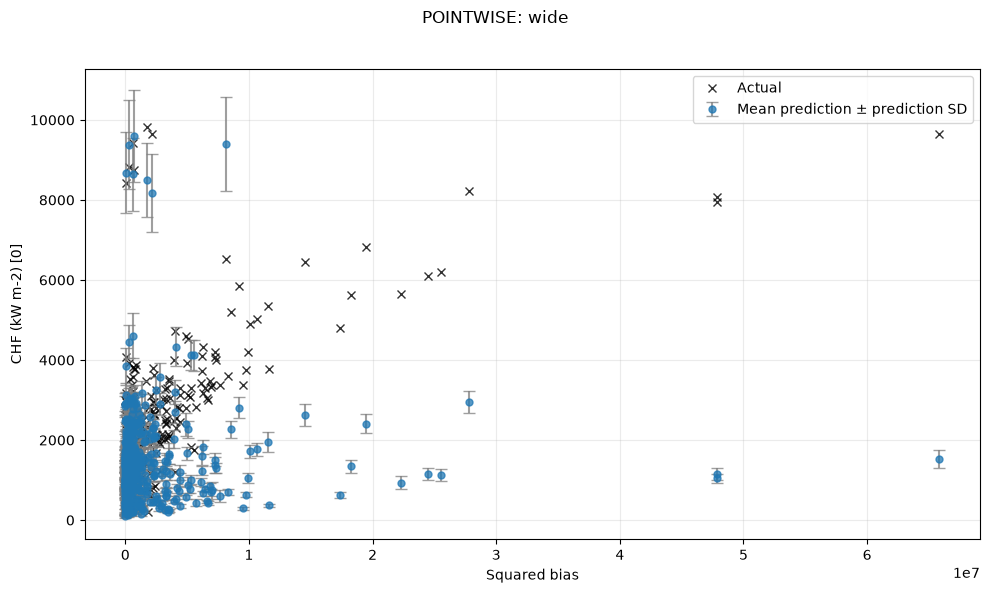

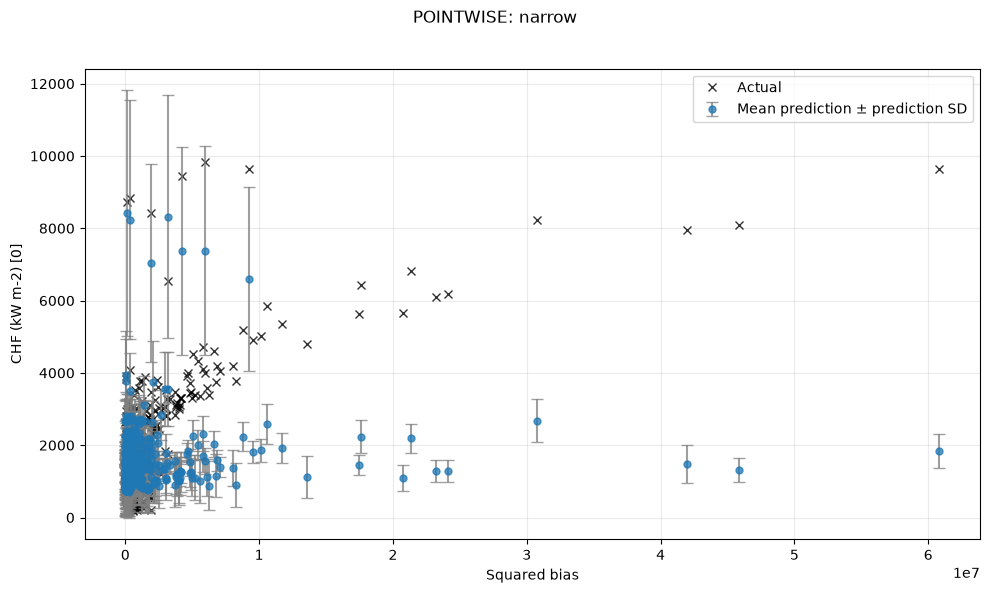

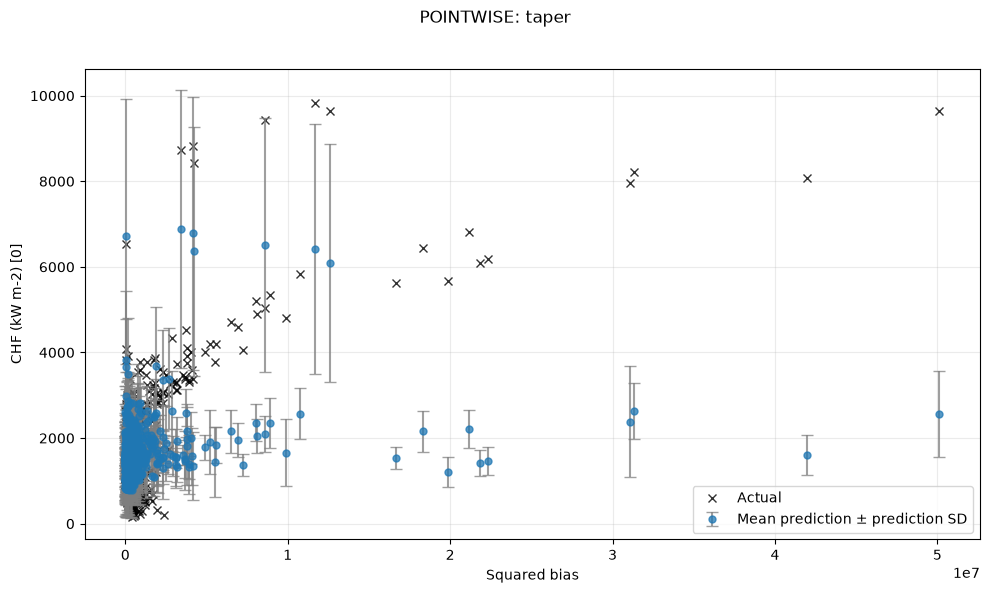

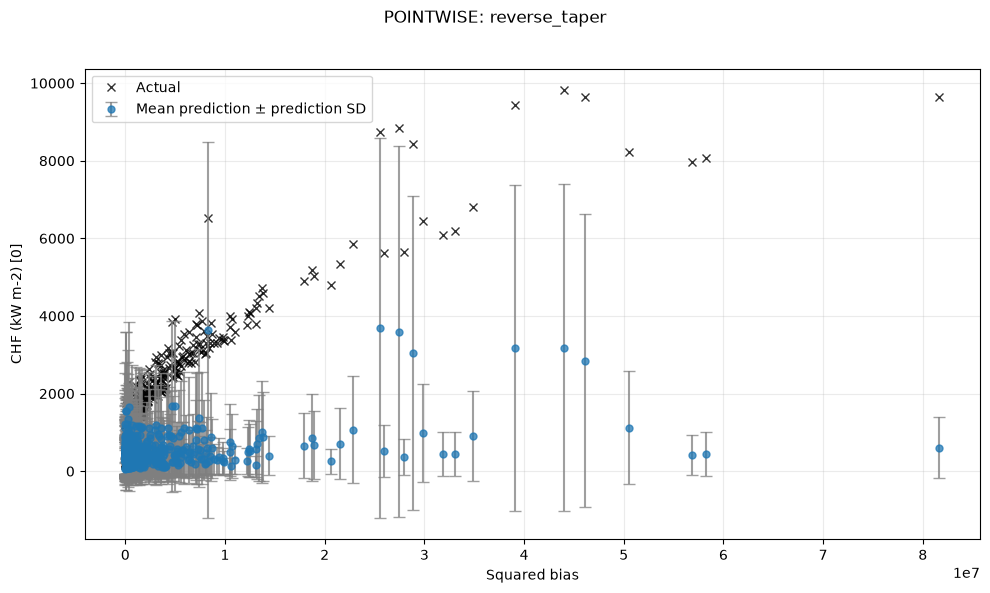

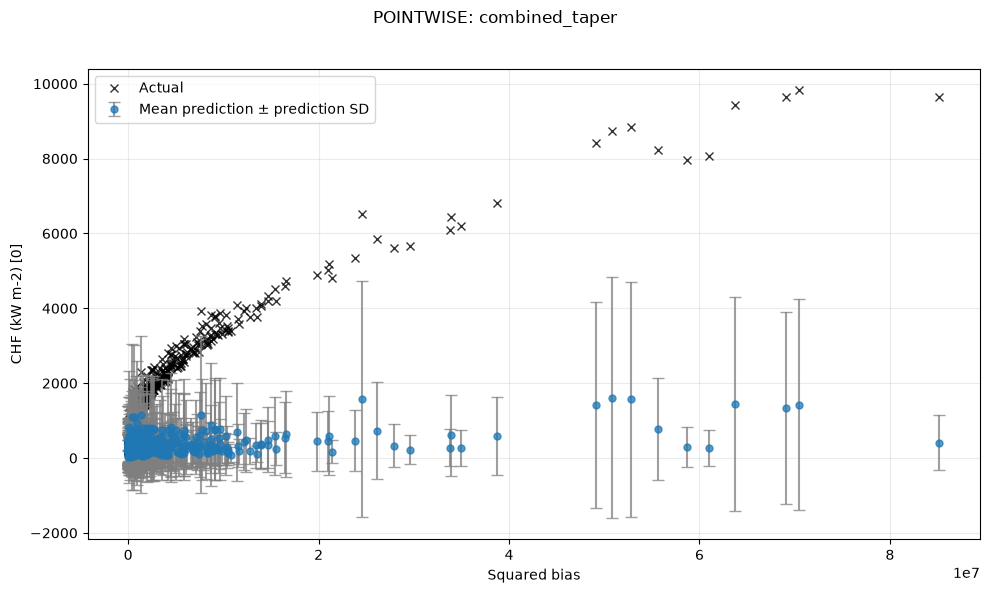

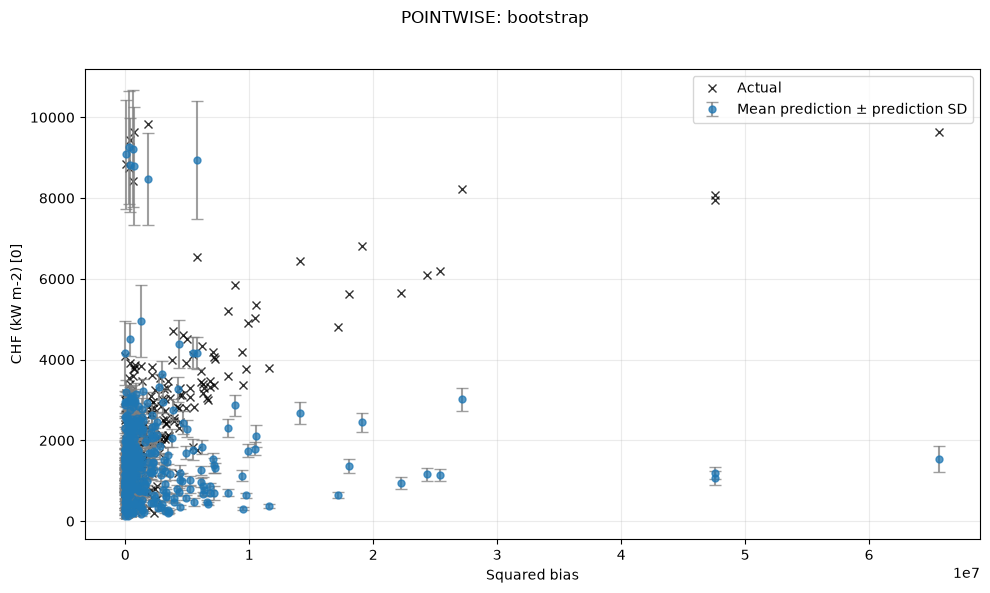

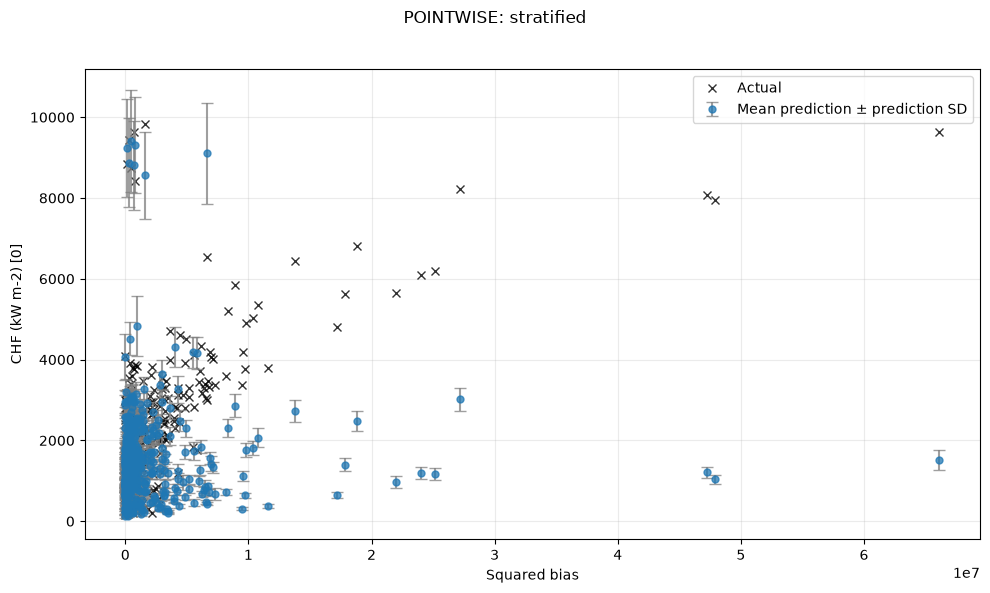

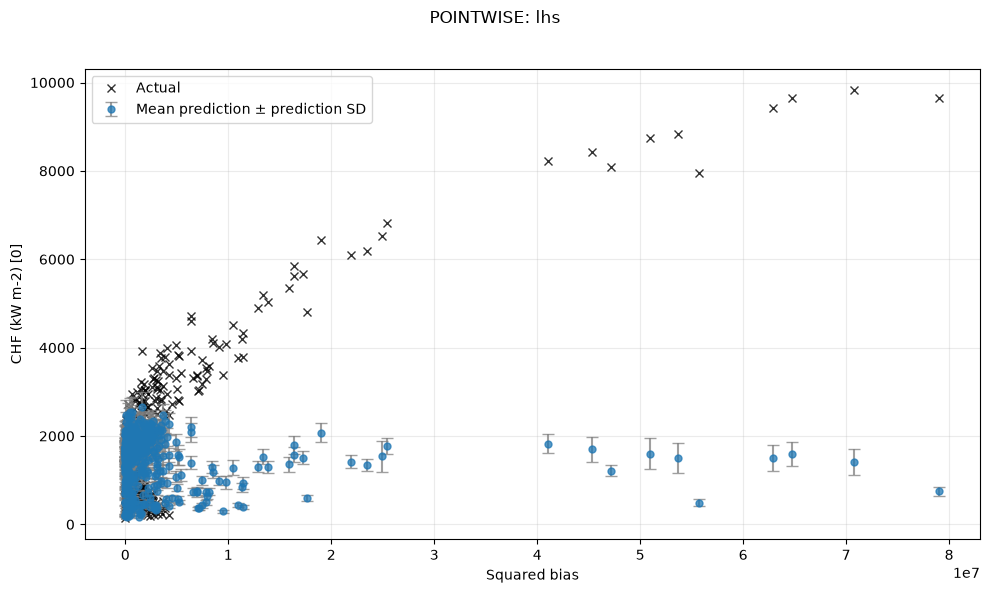

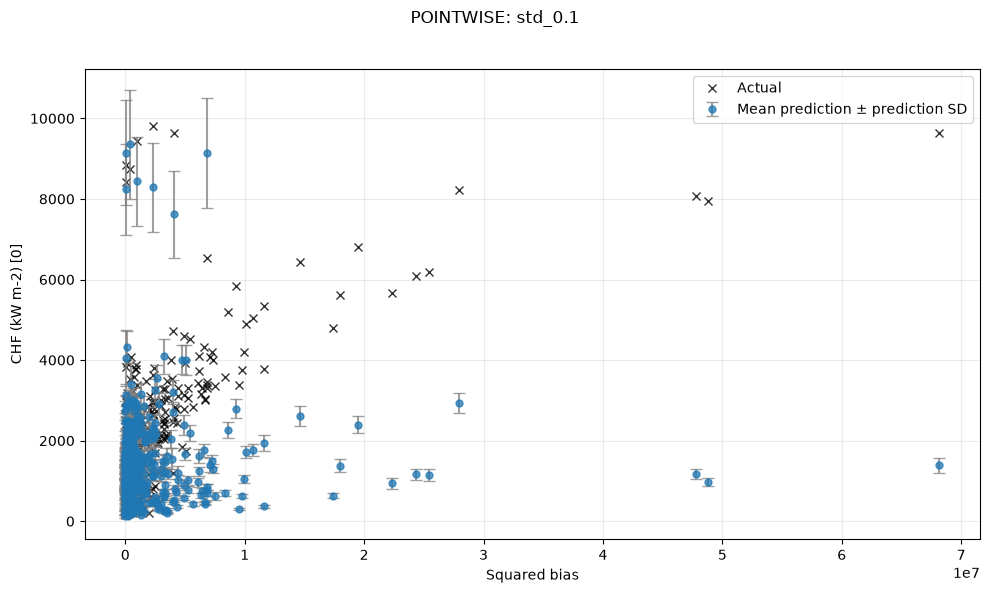

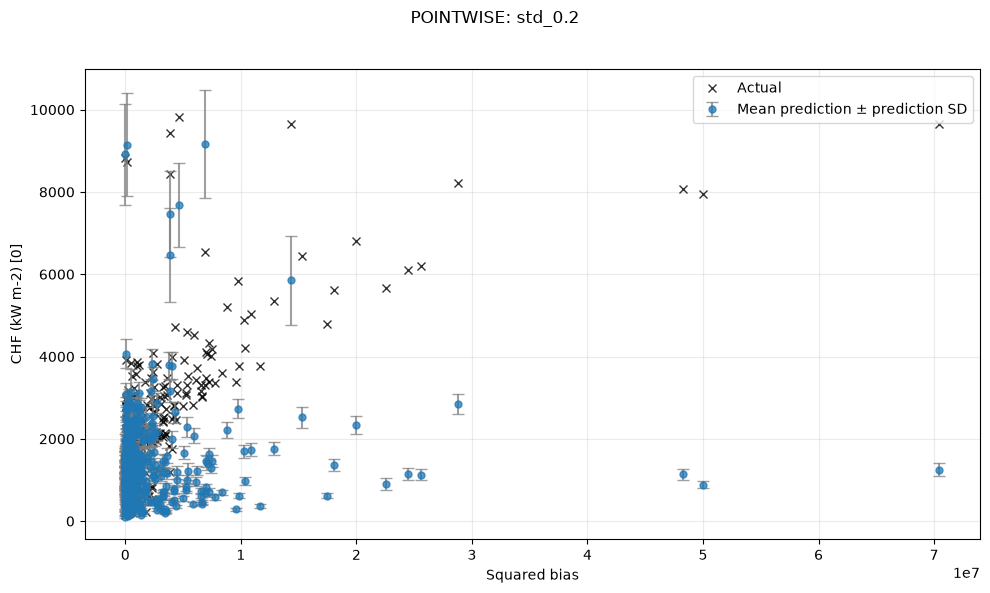

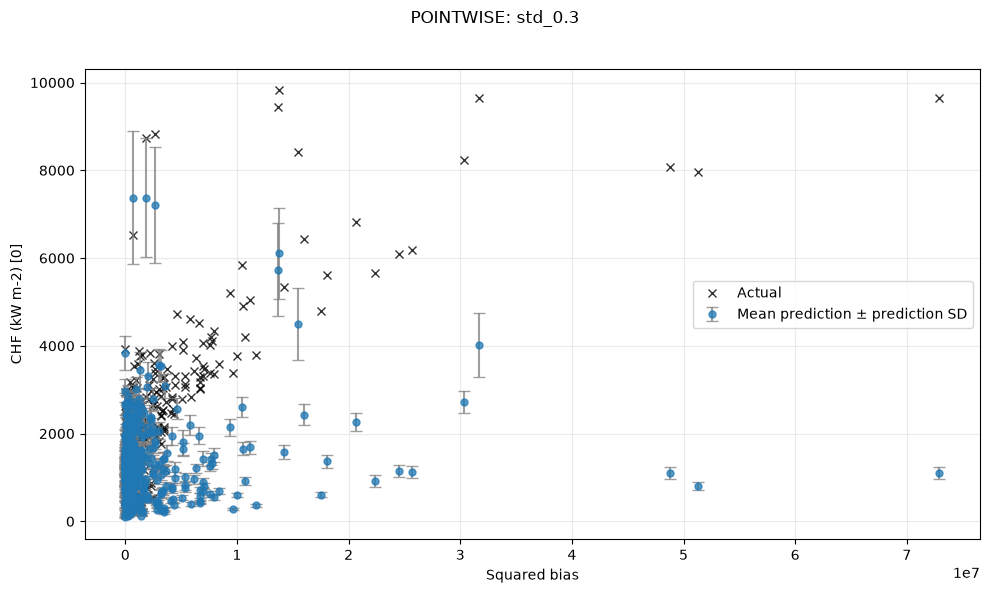

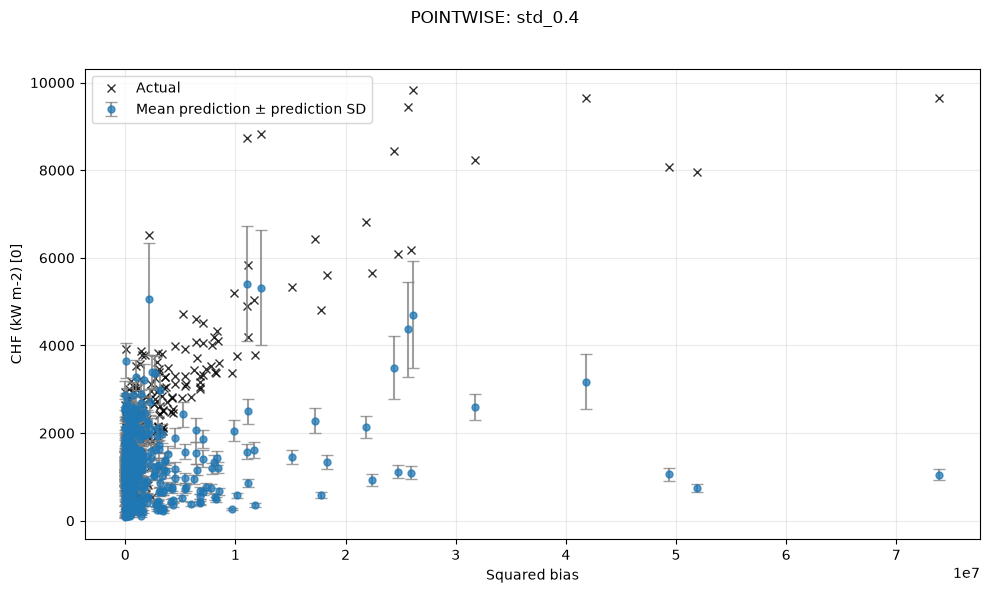

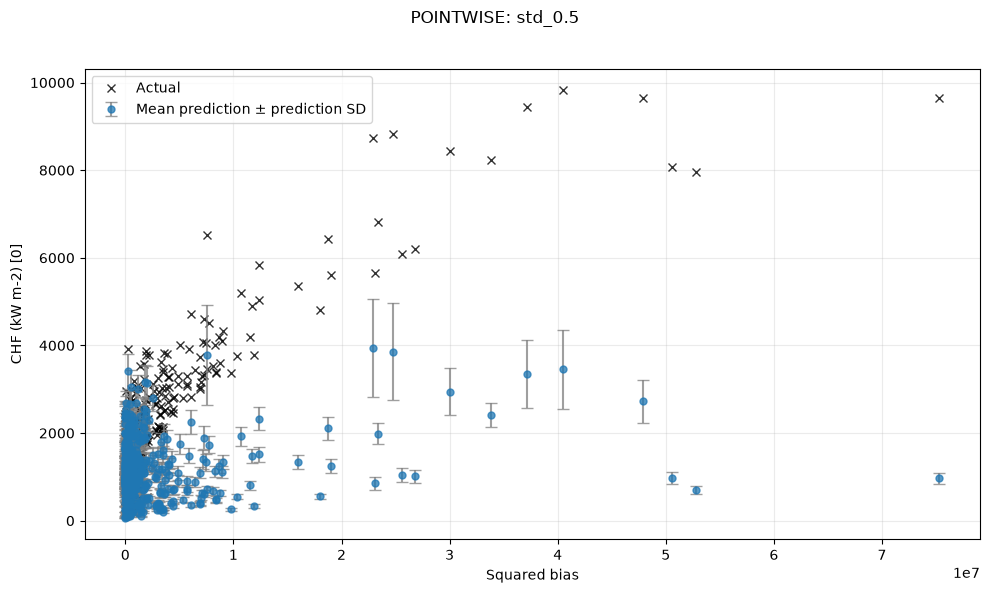

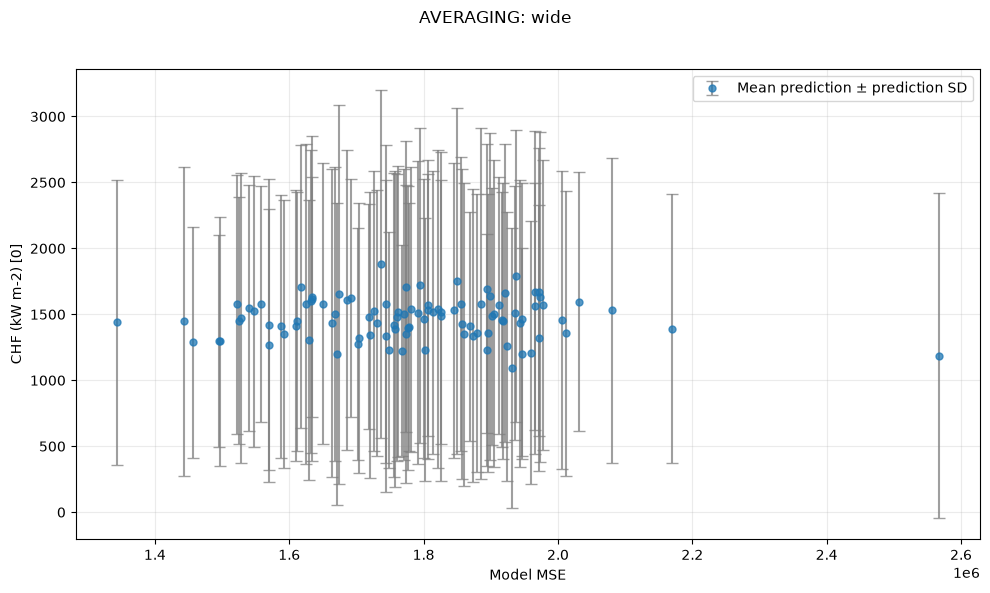

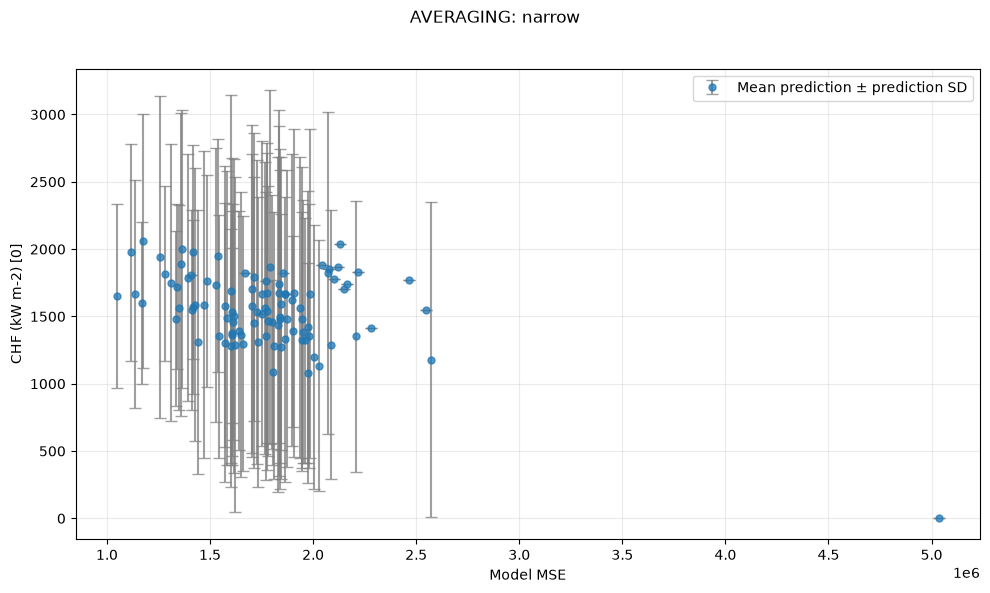

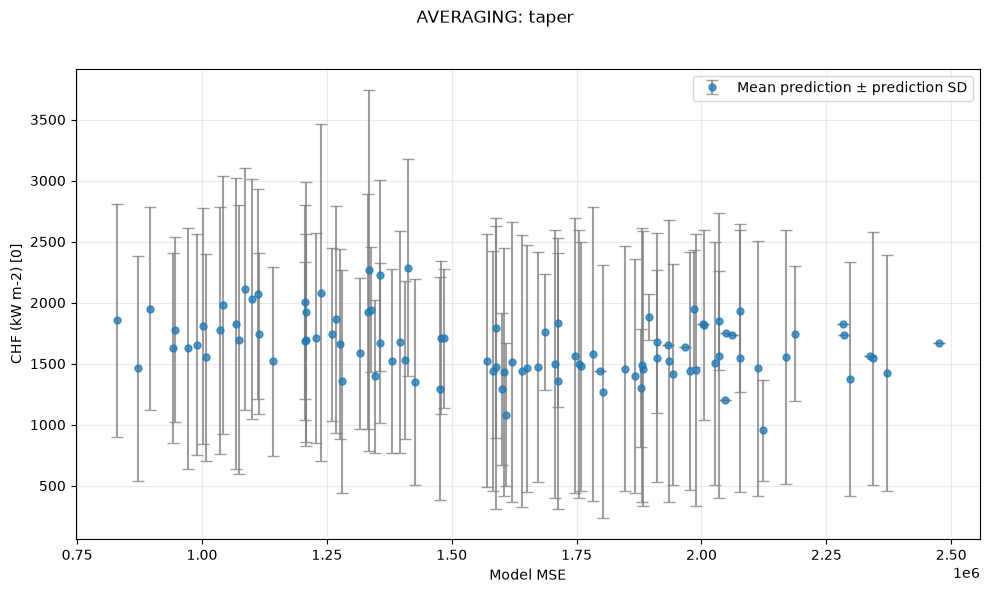

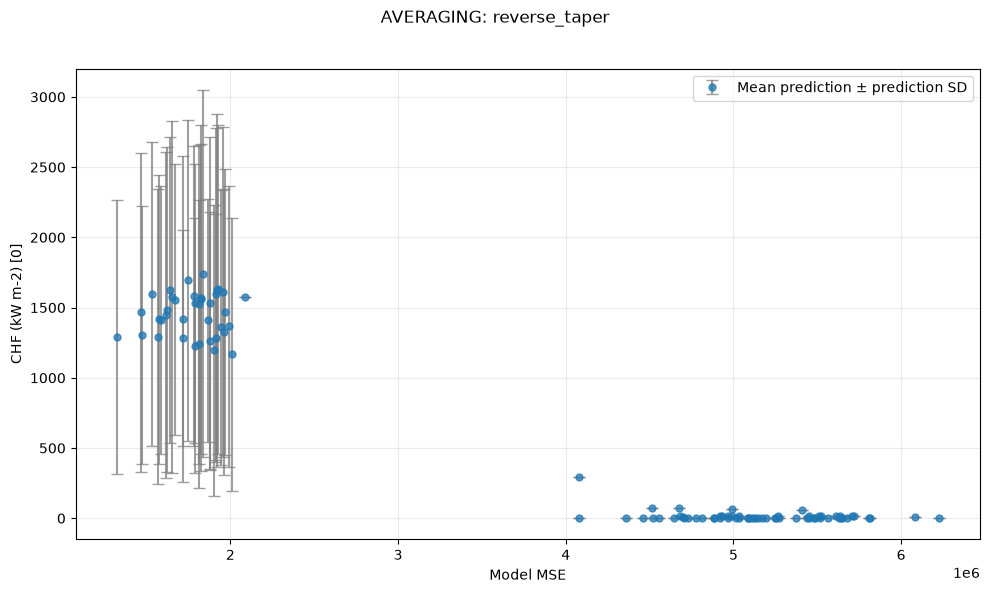

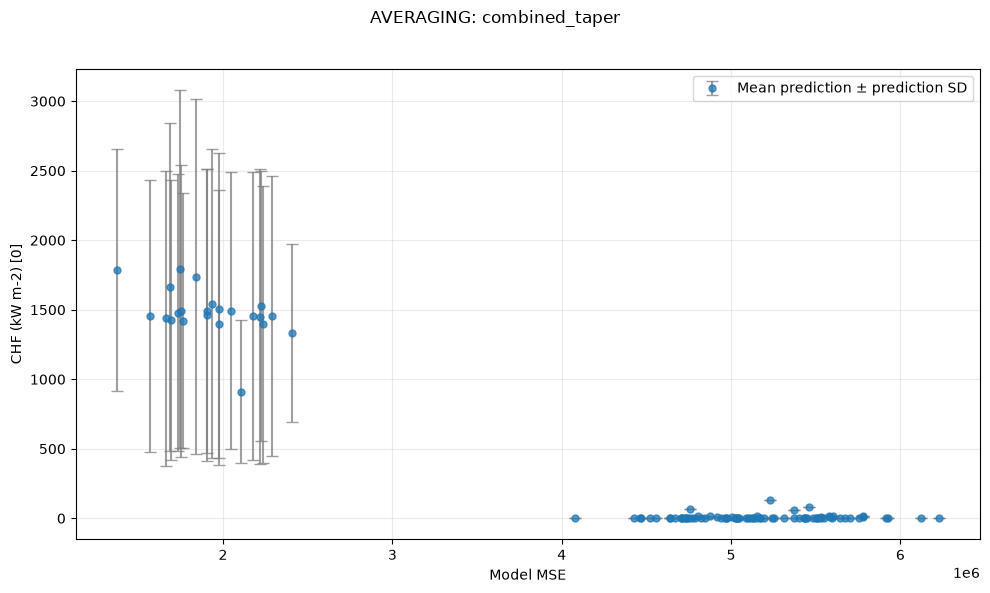

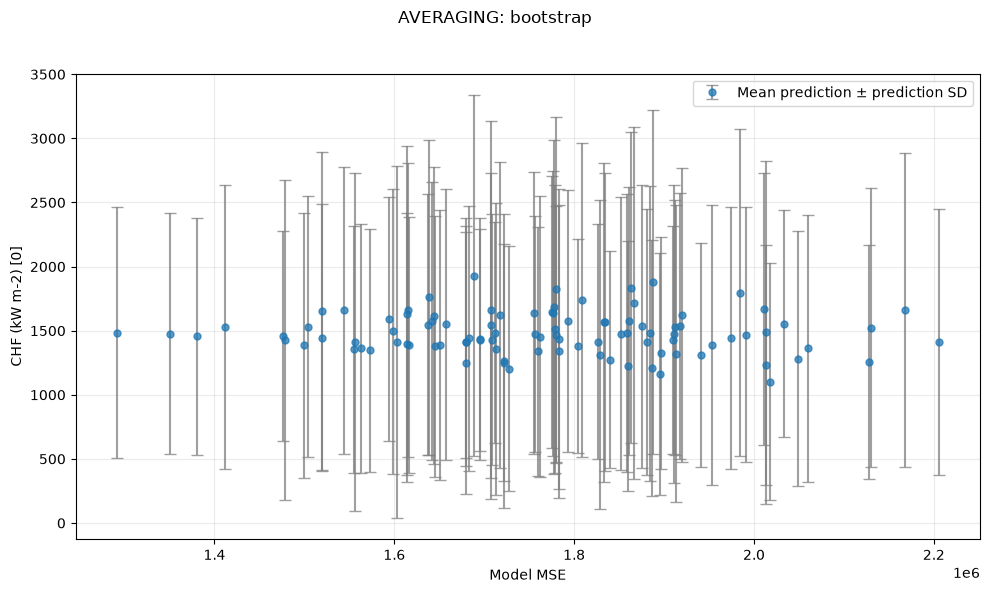

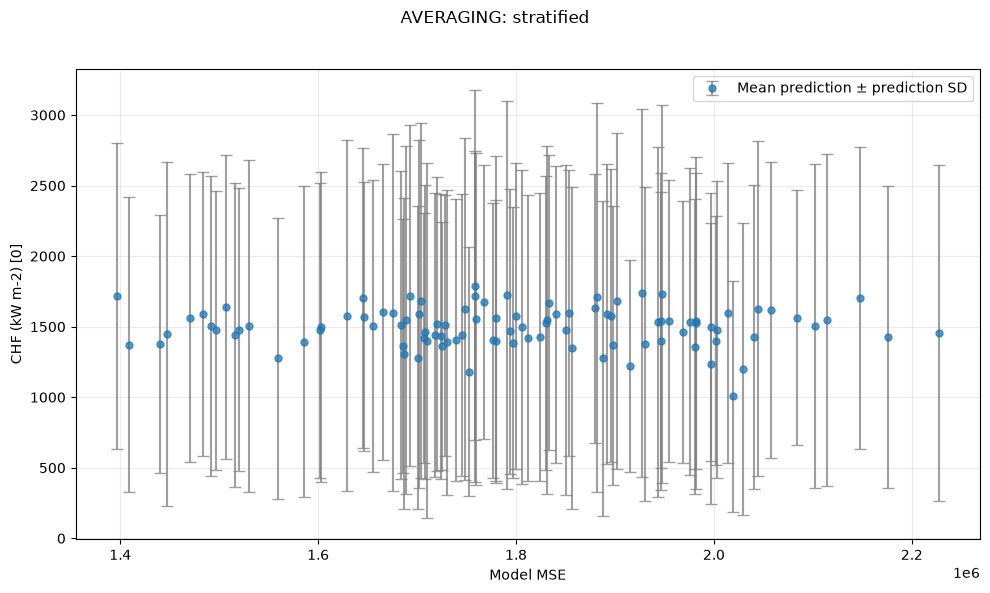

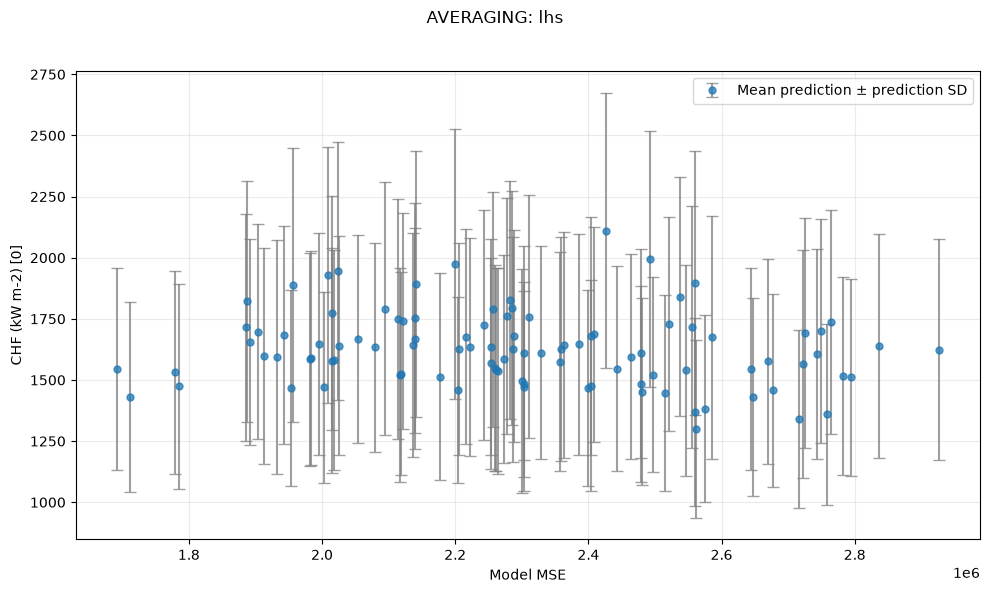

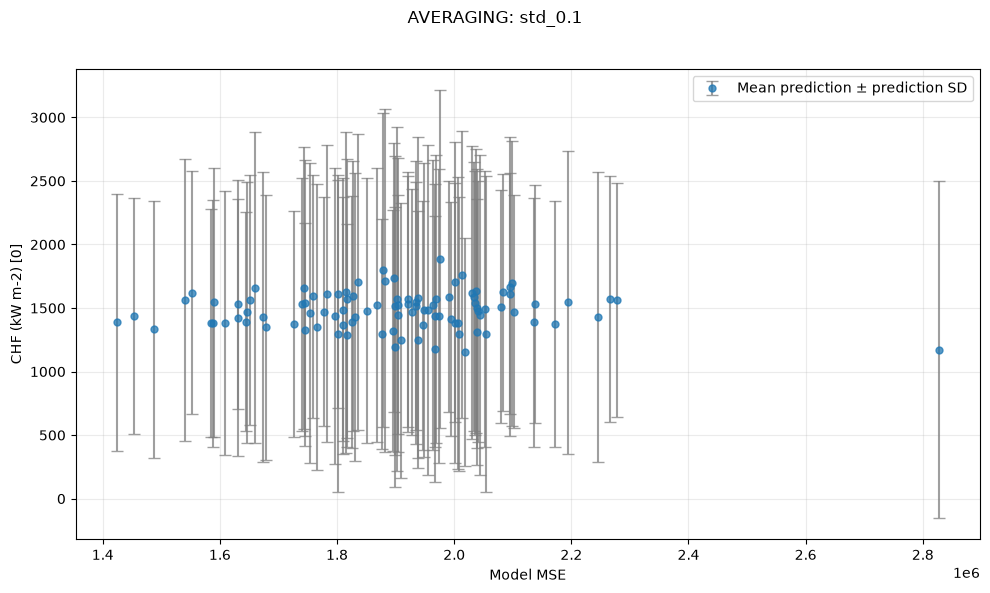

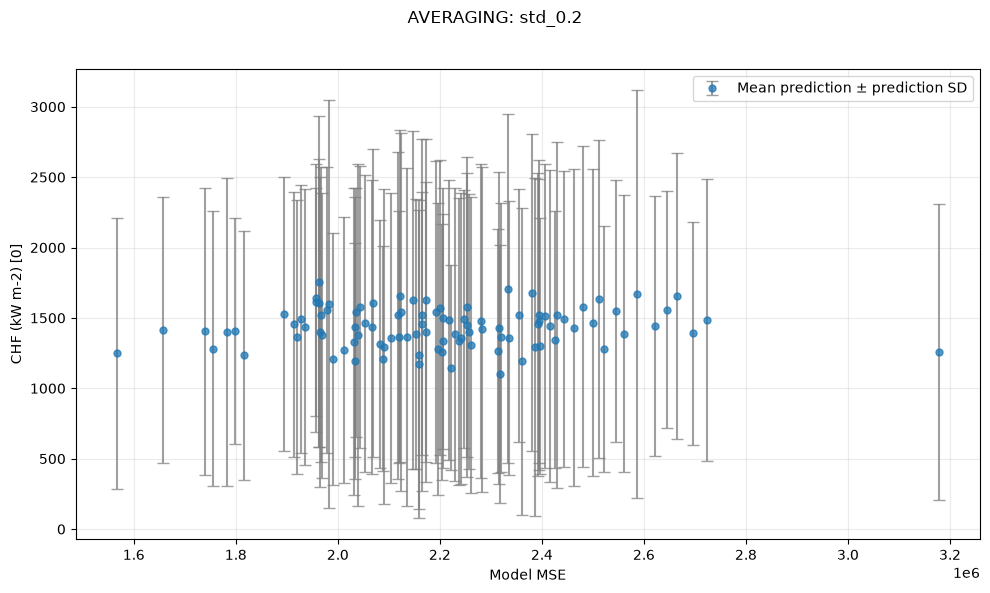

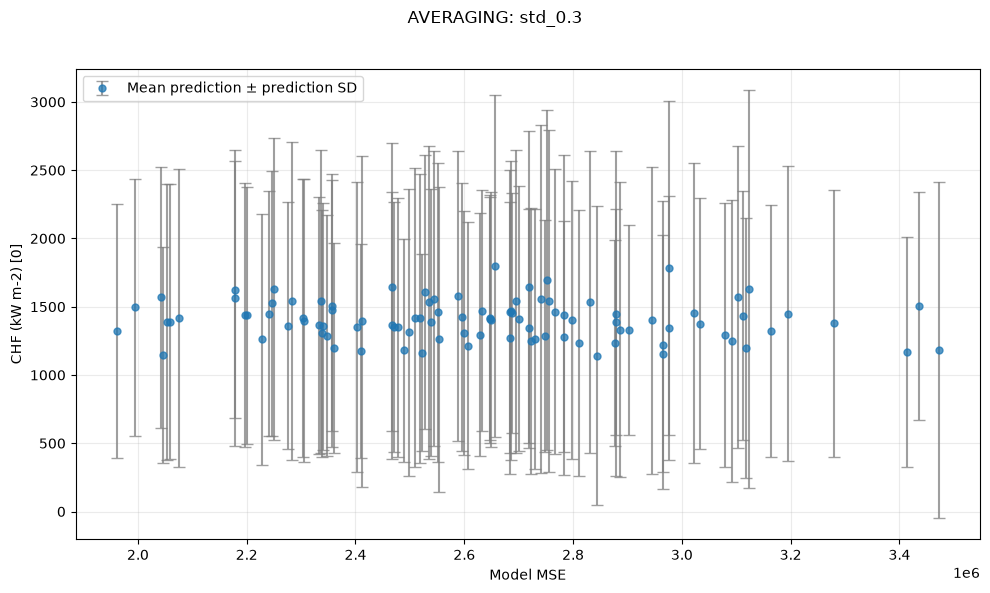

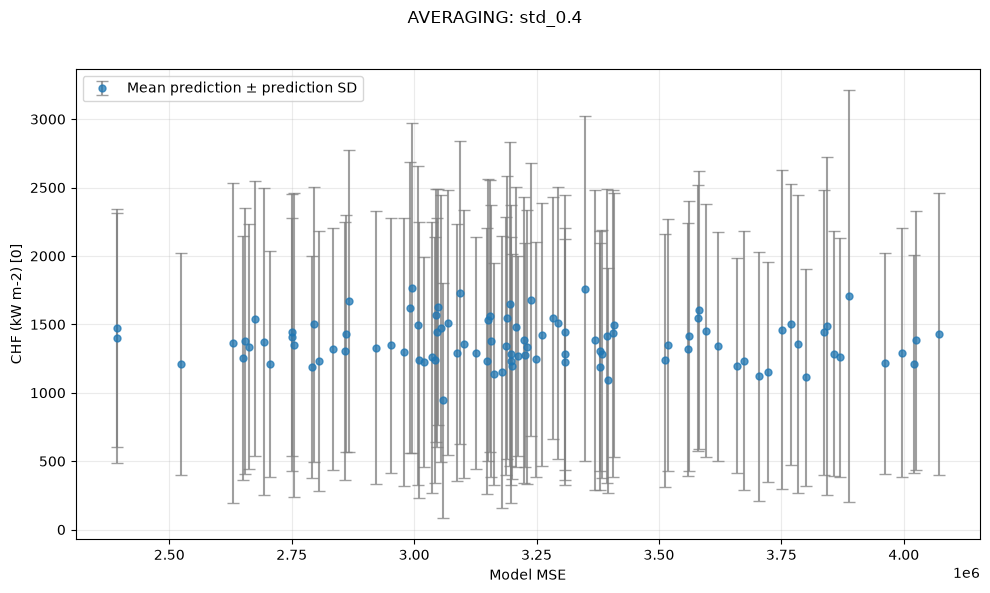

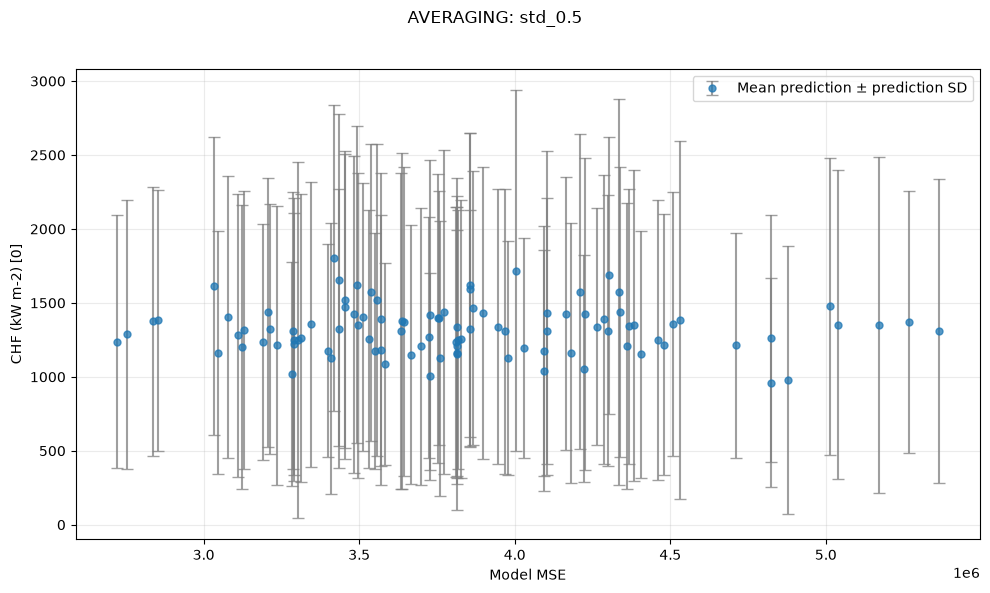

In [10]:
group_plots = analyzer.plot_bias_and_variance(
    plot_data,
    output=TARGET_COLUMNS[0],
    plot_kind="error_relationship",
    max_plots=None,
)
plt.show()

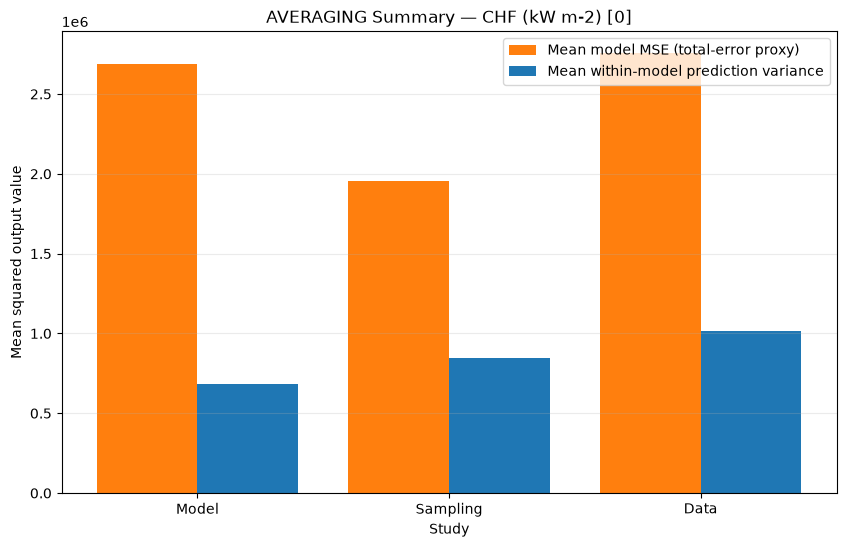

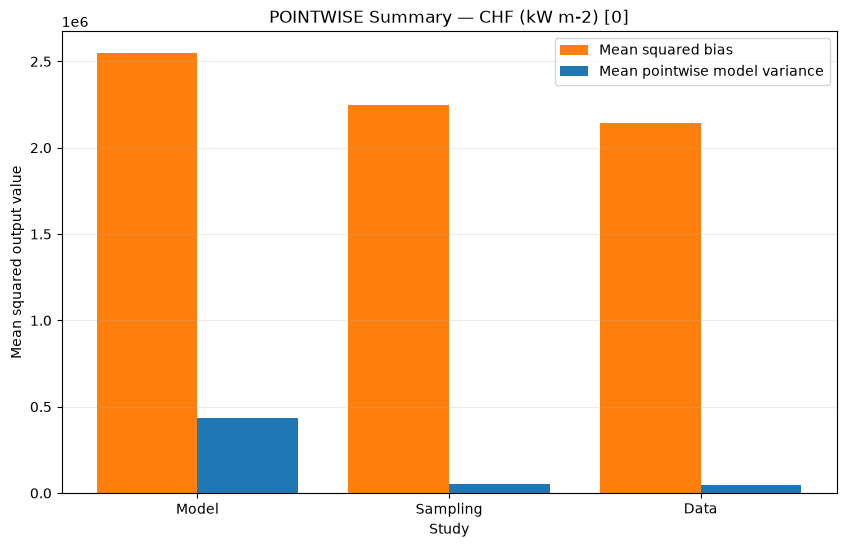

In [7]:
summary_axes = analyzer.plot_summary(plot_data, output=TARGET_COLUMNS[0])
plt.show()

## Reopen an earlier run

Runs remain in the SQLite database. This lets a later notebook session select and plot a run without training the models again.

In [8]:
history = analyzer.get_run_history()
display(history)

# Example for a new session:
# analyzer = BiasAnalyzer(ARTIFACT_DIR / "results.sqlite3")
# analyzer.select_run(history.loc[0, "run_id"])
# plot_data = analyzer.get_bias_variance_plot_data()

,run_id,created_at,n_iter,test_size,test_metrics,optimizer,learning_rate,loss,epochs,batch_size,device,input_columns,output_columns,base_architecture
0,ce1e902e-7b4e-4fbb-b323-2fc40f77288f,2026-08-28 03:00:08.363443+00:00,100,0.2,"(r2, mse)",adam,0.000734,mse,25,16,cuda,"(D (m), L (m), P (kPa), G (kg m-2s-1), Tin (C)...","(CHF (kW m-2),)","(285, 210, 78)"
1,d2d1e97a-15e1-43c3-89eb-0a385ec175b4,2026-08-27 02:25:47.566554+00:00,3,0.2,"(r2, mse)",adam,0.001000,mse,25,32,cpu,"(D (m), L (m), P (kPa), G (kg m-2s-1), Tin (C)...","(CHF (kW m-2),)","(16, 8)"
2,ca911f8d-cd2b-4b4d-b8d4-cdd420198d5b,2026-08-27 02:20:30.152313+00:00,3,0.2,"(r2, mse)",adam,0.001000,mse,25,32,cpu,"(x0, x1, x2, x3)","(target,)","(16, 8)"
